In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["legend.frameon"] = True

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

In [28]:
df_avisos_cholitos = pd.read_csv(
    "../data/df_avisos_cholitos.csv",
    encoding="utf-8",
    parse_dates=["primera_fecha"]
)

df_fuentes = pd.read_csv(
    "../data/df_fuentes.csv",
    encoding="utf-8",
    parse_dates=["fecha"]
)

df_fuentes_por_aviso = pd.read_csv(
    "../data/df_fuentes_por_aviso.csv",
    encoding="utf-8"
)

In [41]:
def mascara_valida(serie: pd.Series) -> pd.Series:
    return serie.notna() & (serie != "Desconocido")

In [29]:
columnas_relevantes = [
    "edad_num", "estatura_macro", "complexion_macro", "cara_macro",
    "ojos_macro", "nariz_macro", "boca_macro", "frente_macro",
    "longitud_cabello_macro", "peinado_macro", "camisa_macro",
    "pantalon_macro", "color_piel_macro"
]

columnas_categoricas = [c for c in columnas_relevantes if c != "edad_num"]

In [ ]:
def estacion_hemisferio_sur(mes: int) -> str:
    if mes in (12, 1, 2):
        return "Verano"
    if mes in (3, 4, 5):
        return "Otoño"
    if mes in (6, 7, 8):
        return "Invierno"
    return "Primavera"


df_av = df_avisos_cholitos.copy()

df_av["anio"] = df_av["primera_fecha"].dt.year
df_av["mes"] = df_av["primera_fecha"].dt.month
df_av["decada"] = (df_av["anio"] // 10) * 10
df_av["estacion"] = df_av["mes"].apply(estacion_hemisferio_sur)
df_av["anio_estacion"] = df_av["anio"].astype("Int64").astype(str) + " - " + df_av["estacion"].astype(str)
df_av["periodo_decada"] = df_av["decada"].astype("Int64").astype(str) + "s"

In [71]:
def cobertura_por_periodo(df: pd.DataFrame, periodo_col: str, cols: list[str]) -> pd.DataFrame:
    resultados = []

    for col in cols:
        tmp = df[[periodo_col, col]].copy()

        tmp["informativo"] = tmp[col] != "Desconocido"

        res = (
            tmp.groupby(periodo_col, dropna=False)["informativo"]
            .agg(
                n_total="size",
                n_informativos="sum",
                cobertura="mean"
            )
            .reset_index()
        )

        res["variable"] = col
        resultados.append(res)

    return pd.concat(resultados, ignore_index=True)

cobertura_decada = cobertura_por_periodo(df_av, "periodo_decada", columnas_relevantes)
cobertura_anio = cobertura_por_periodo(df_av, "anio", columnas_relevantes)
cobertura_estacion = cobertura_por_periodo(df_av, "estacion", columnas_relevantes)
cobertura_anio_estacion = cobertura_por_periodo(df_av, "anio_estacion", columnas_relevantes)

In [35]:
resumen_cobertura = (
    cobertura_decada.groupby("variable")
    .agg(
        cobertura_media=("cobertura", "mean"),
        cobertura_std=("cobertura", "std"),
        cobertura_min=("cobertura", "min"),
        cobertura_max=("cobertura", "max"),
        periodos=("periodo_decada", "nunique")
    )
    .sort_values(["cobertura_media", "cobertura_std"], ascending=[False, True])
    .reset_index()
)

resumen_cobertura

,variable,cobertura_media,cobertura_std,cobertura_min,cobertura_max,periodos
0,edad_num,0.917636,0.008108,0.911504,0.926829,3
1,color_piel_macro,0.479001,0.416527,0.000000,0.756098,3
2,cara_macro,0.196143,0.171396,0.000000,0.317073,3
3,camisa_macro,0.164338,0.143088,0.000000,0.261307,3
4,ojos_macro,0.147342,0.132338,0.000000,0.256098,3
5,nariz_macro,0.143277,0.127423,0.000000,0.243902,3
6,complexion_macro,0.125465,0.108783,0.000000,0.193467,3
7,pantalon_macro,0.109552,0.096681,0.000000,0.182927,3
8,estatura_macro,0.098787,0.088474,0.000000,0.170732,3
9,longitud_cabello_macro,0.072006,0.066343,0.000000,0.130653,3


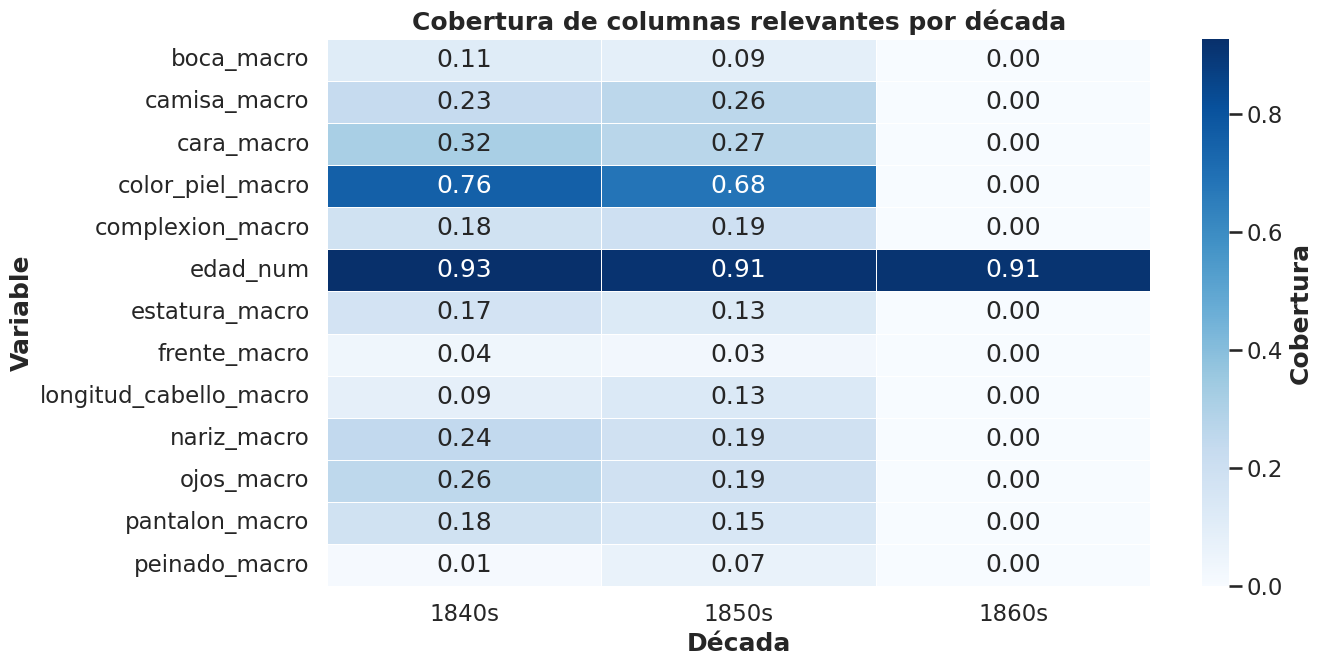

In [72]:
pivot_cob = cobertura_decada.pivot_table(
    index="variable",
    columns="periodo_decada",
    values="cobertura",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(14, 7))
ax = sns.heatmap(
    pivot_cob,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Coverage"}
)
ax.set_title("Coverage of Relevant Variables by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

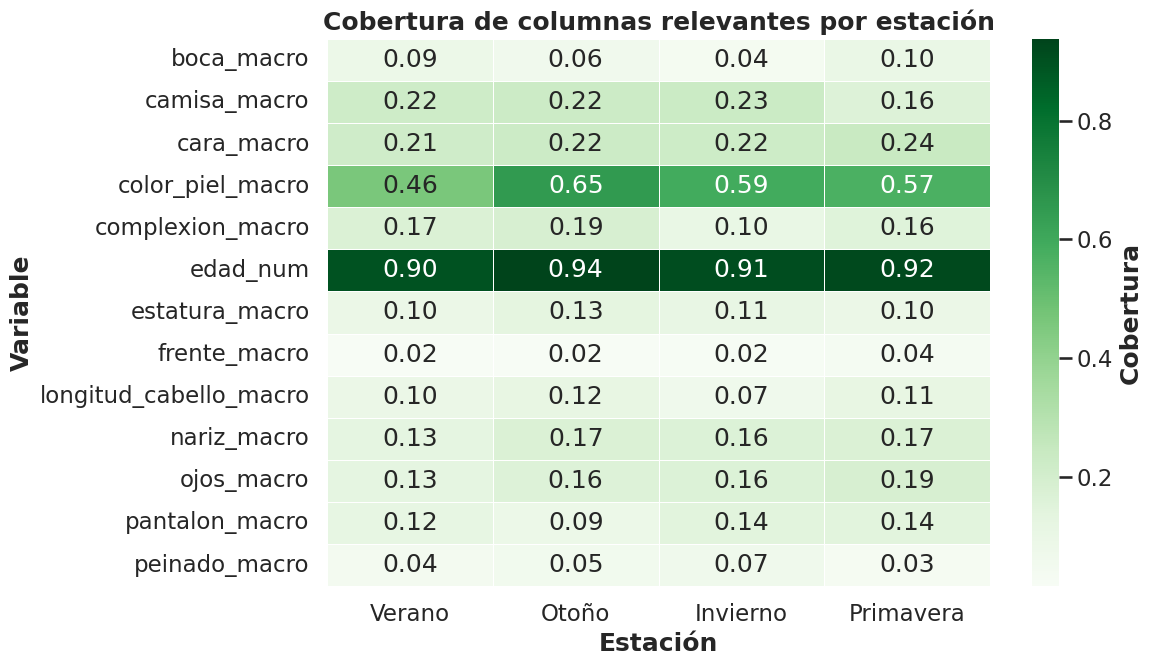

In [73]:
orden_estaciones = ["Verano", "Otoño", "Invierno", "Primavera"]

pivot_est = cobertura_estacion.pivot_table(
    index="variable",
    columns="estacion",
    values="cobertura",
    aggfunc="mean"
).reindex(columns=orden_estaciones).rename(columns={
        "Verano": "Summer",
        "Otoño": "Autumn",
        "Invierno": "Winter",
        "Primavera": "Spring"
    })

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    pivot_est,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Coverage"}
)
ax.set_title("Coverage of Relevant Variables by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

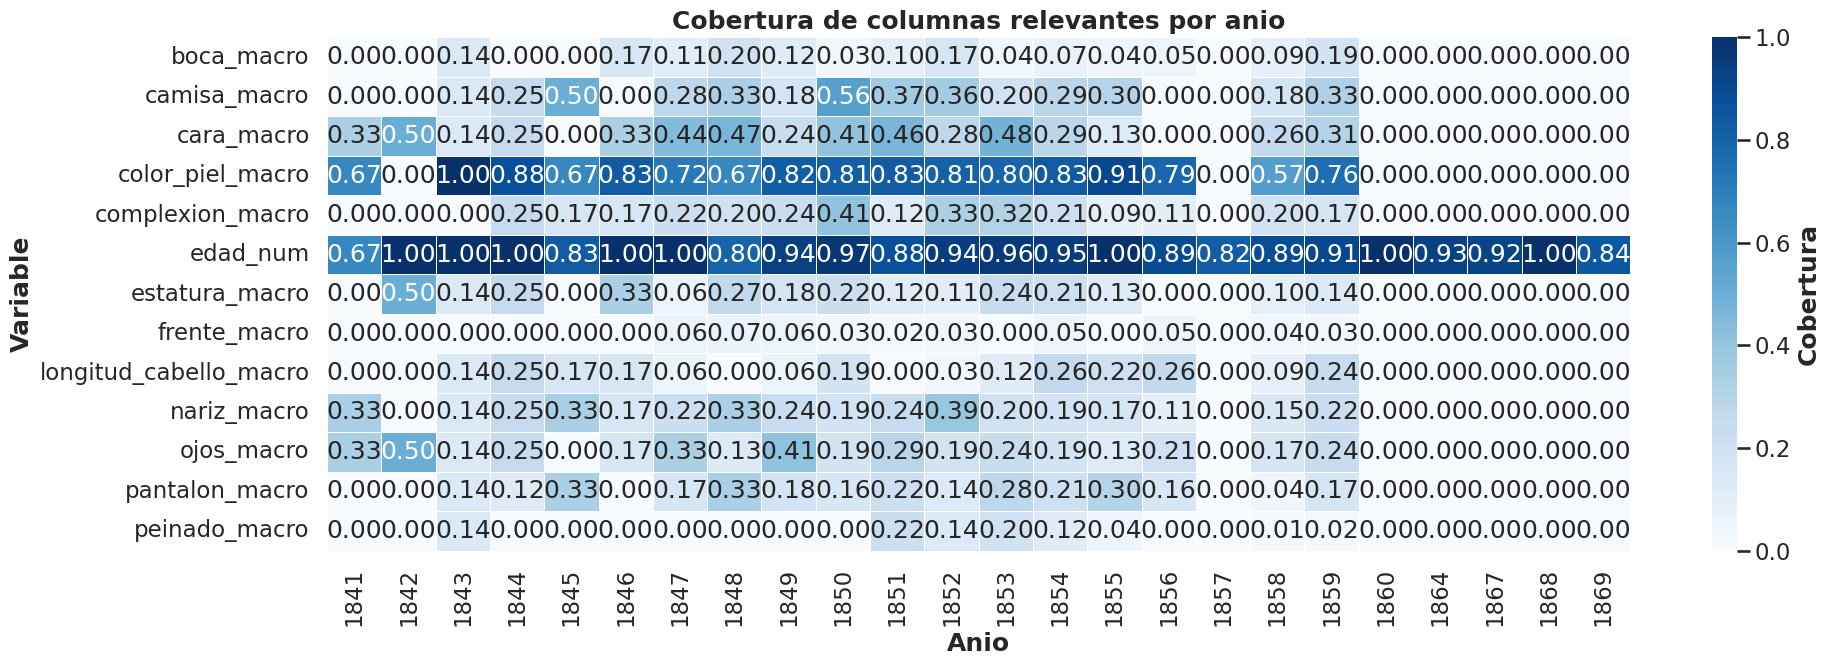

In [75]:
pivot_anio = cobertura_anio.pivot_table(
    index="variable",
    columns="anio",
    values="cobertura",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(20, 7))
ax = sns.heatmap(
    pivot_anio,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Coverage"}
)
ax.set_title("Coverage of Relevant Variables by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

In [42]:
def top_valores_por_periodo(df: pd.DataFrame, periodo_col: str, variable: str, top_n: int = 5) -> pd.DataFrame:
    tmp = df[[periodo_col, variable]].copy()
    tmp = tmp[mascara_valida(tmp[variable])]

    res = (
        tmp.groupby([periodo_col, variable], dropna=False)
        .size()
        .reset_index(name="frecuencia")
    )

    res["total_periodo"] = res.groupby(periodo_col)["frecuencia"].transform("sum")
    res["share"] = res["frecuencia"] / res["total_periodo"]

    # Top n per period
    res = res.sort_values([periodo_col, "frecuencia"], ascending=[True, False])
    res["rank"] = res.groupby(periodo_col)["frecuencia"].rank(method="first", ascending=False)

    return res[res["rank"] <= top_n].copy()

In [43]:
def plot_top_valores_por_periodo(df: pd.DataFrame, periodo_col: str, variable: str, top_n: int = 5):
    res = top_valores_por_periodo(df, periodo_col, variable, top_n=top_n)

    if res.empty:
        print(f"No valid data for {variable}")
        return

    # Global top categories to avoid cluttering the legend
    top_global = (
        res.groupby(variable)["frecuencia"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )
    res = res[res[variable].isin(top_global)].copy()

    pivot = res.pivot_table(
        index=periodo_col,
        columns=variable,
        values="share",
        aggfunc="mean"
    ).fillna(0)

    pivot = pivot.sort_index()

    periodo_label = {
        "anio": "Year",
        "estacion": "Season",
        "periodo_decada": "Decade",
        "anio_estacion": "Year - Season"
    }.get(periodo_col, periodo_col)

    fig, ax = plt.subplots(figsize=(14, 6))
    pivot.plot(ax=ax, marker="o", linewidth=2)

    ax.set_title(f"Top {top_n} Most Frequent Values of {variable} by {periodo_label}")
    ax.set_xlabel(periodo_label)
    ax.set_ylabel("Proportion within Period")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title=variable, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

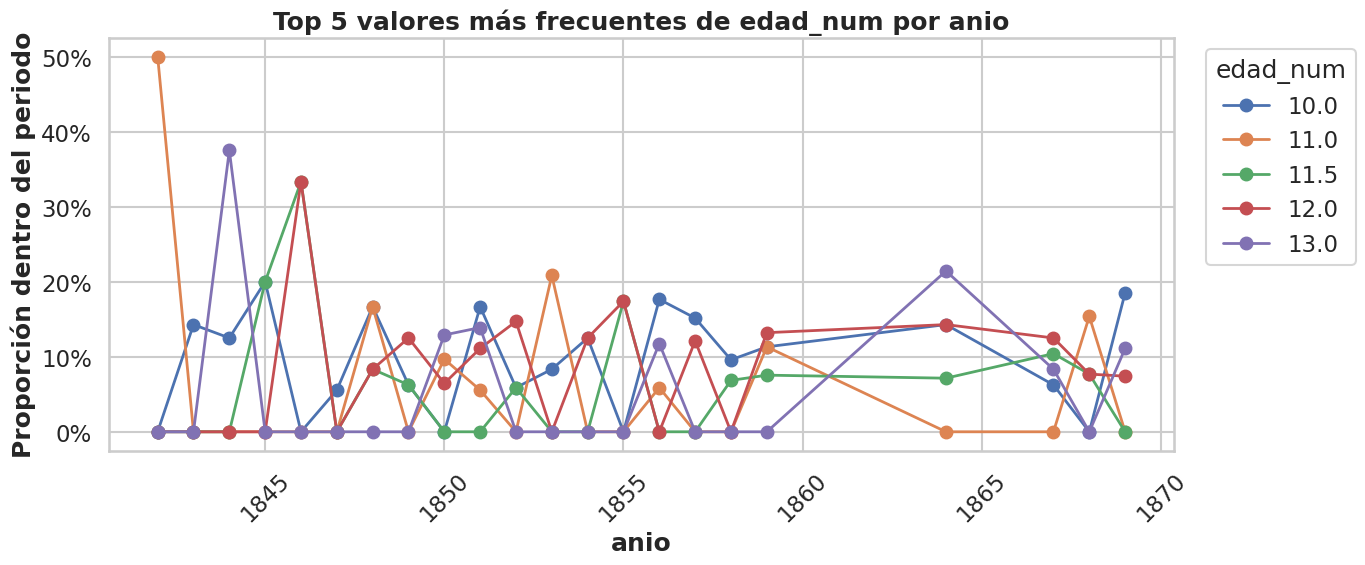

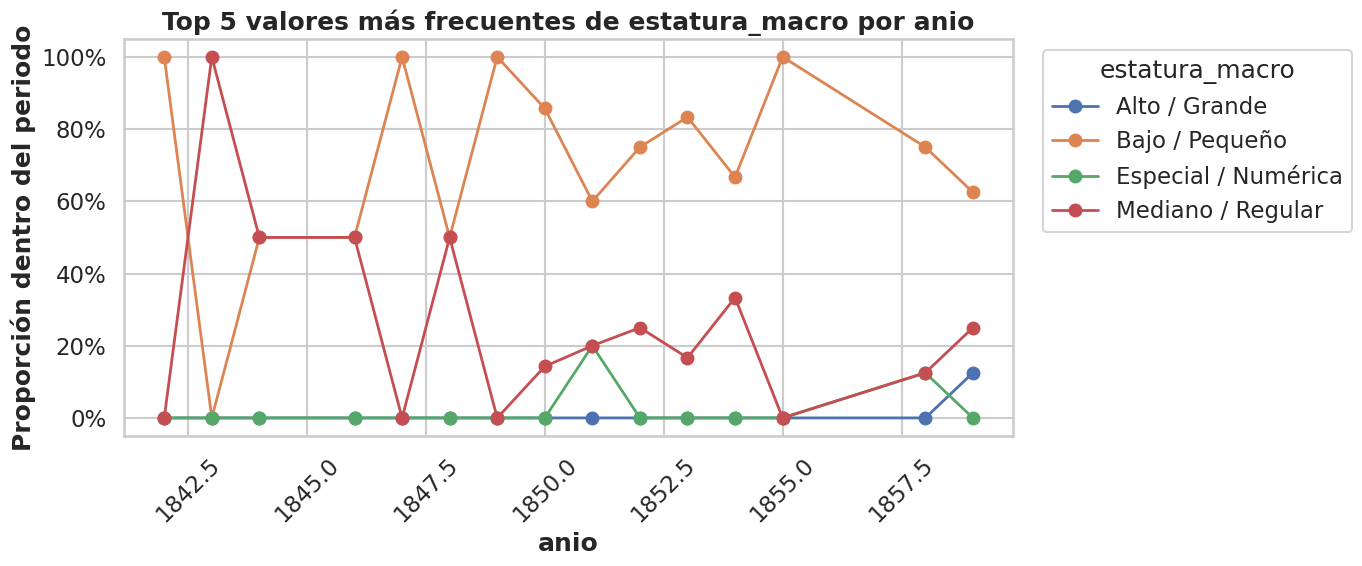

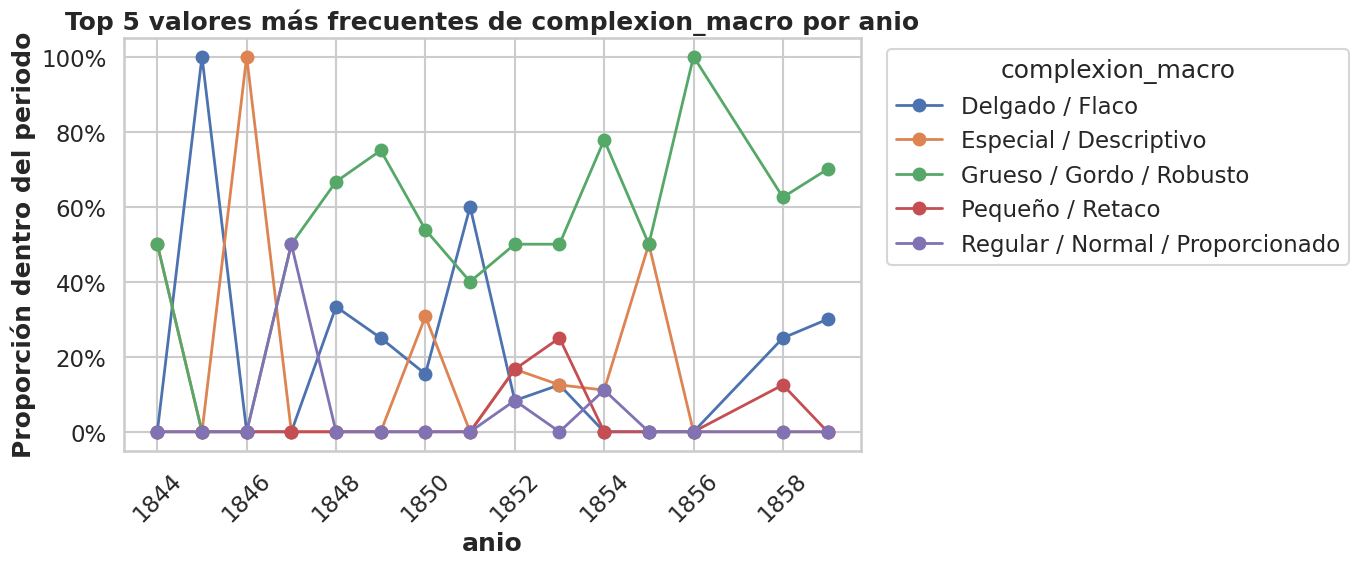

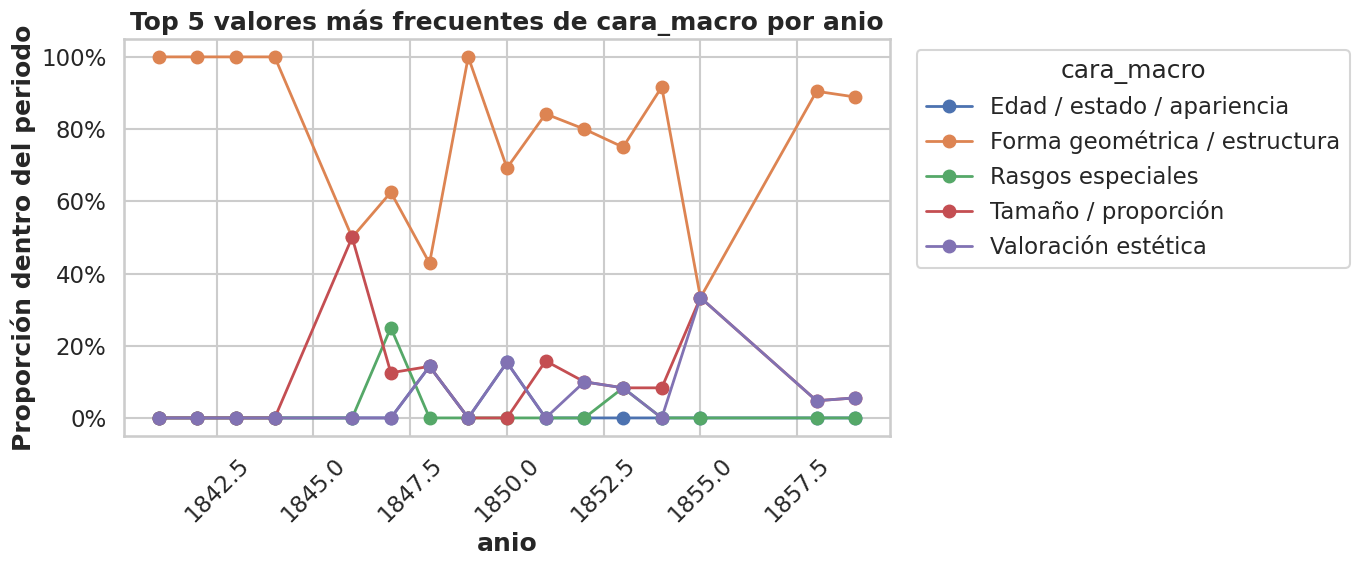

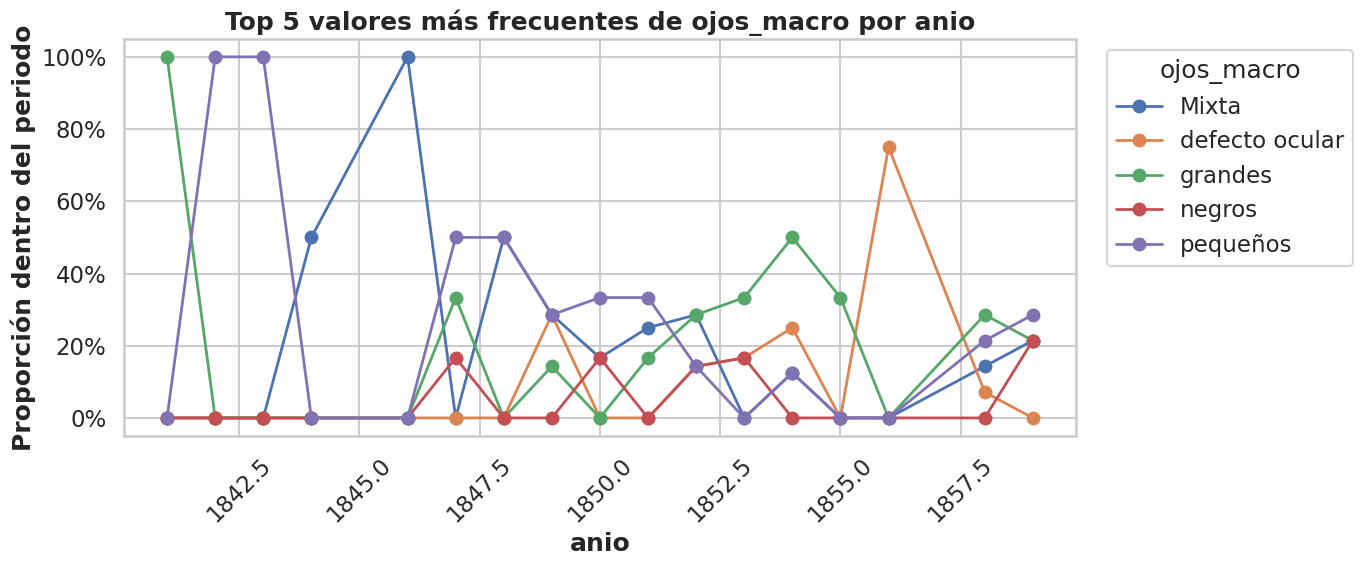

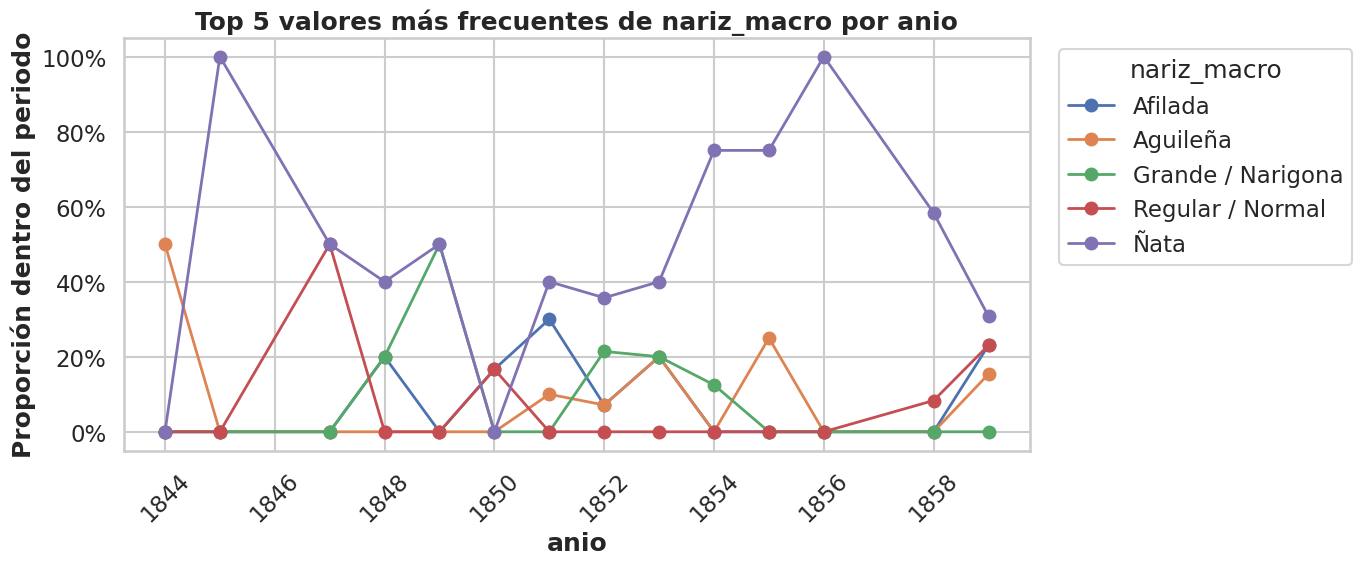

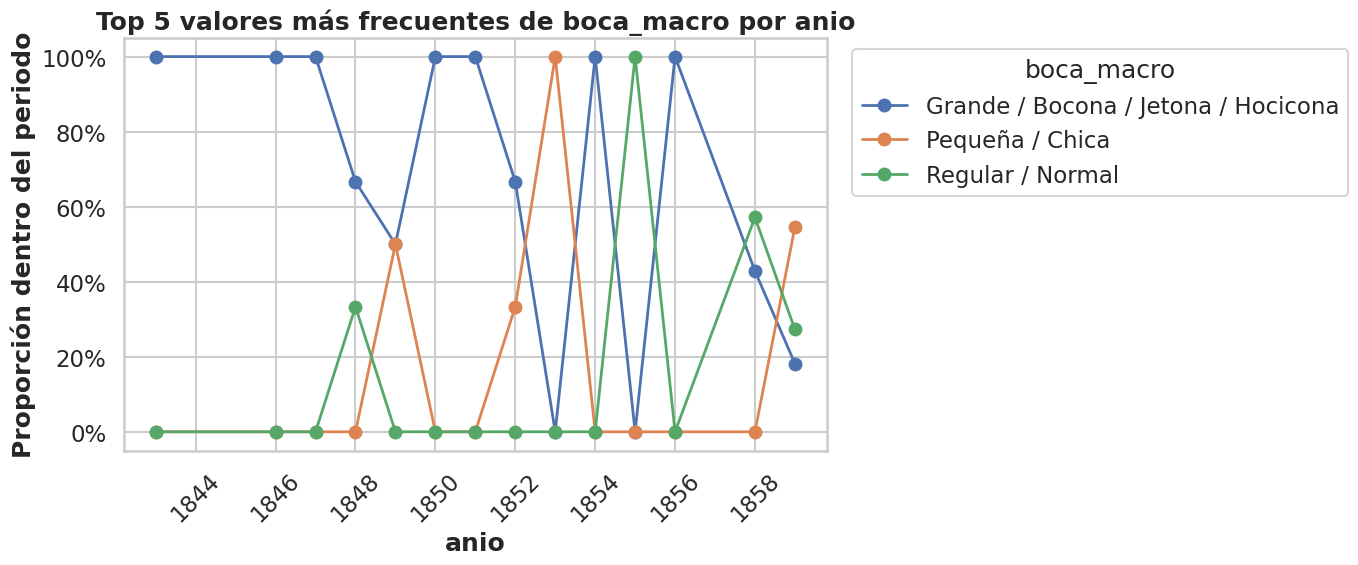

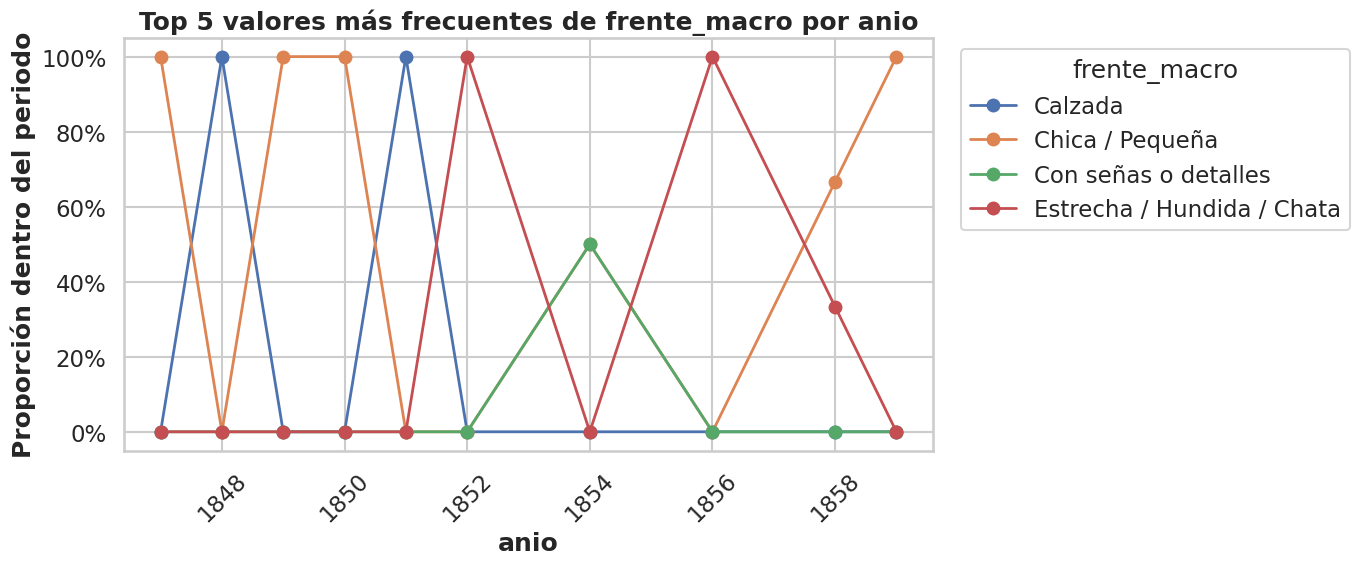

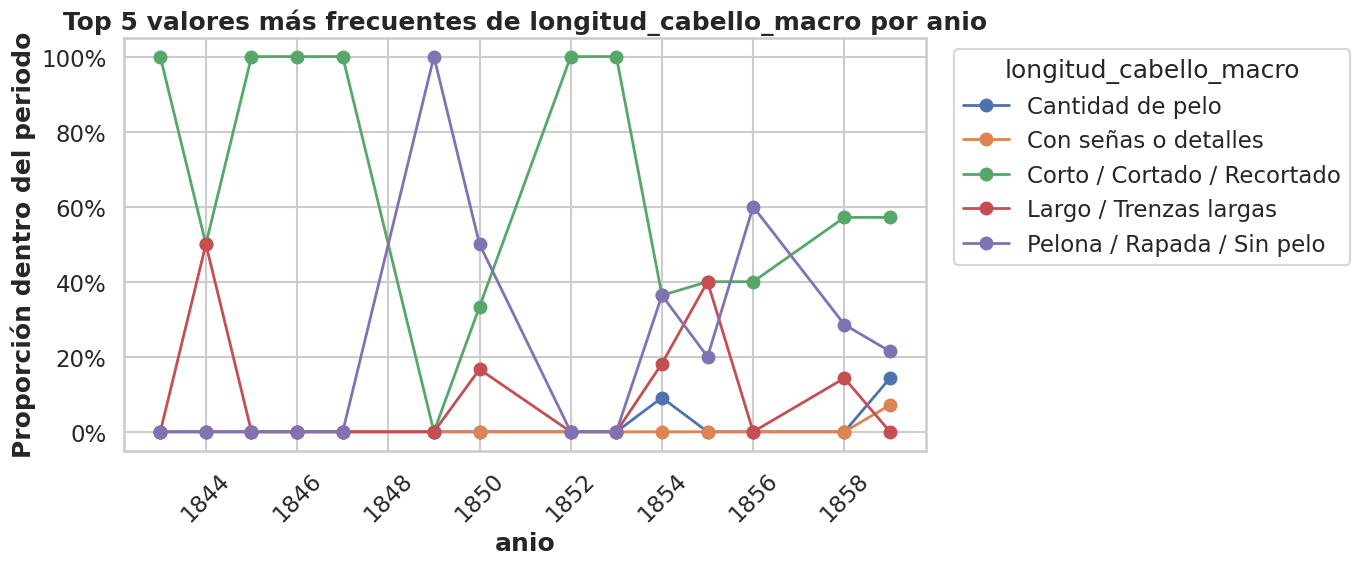

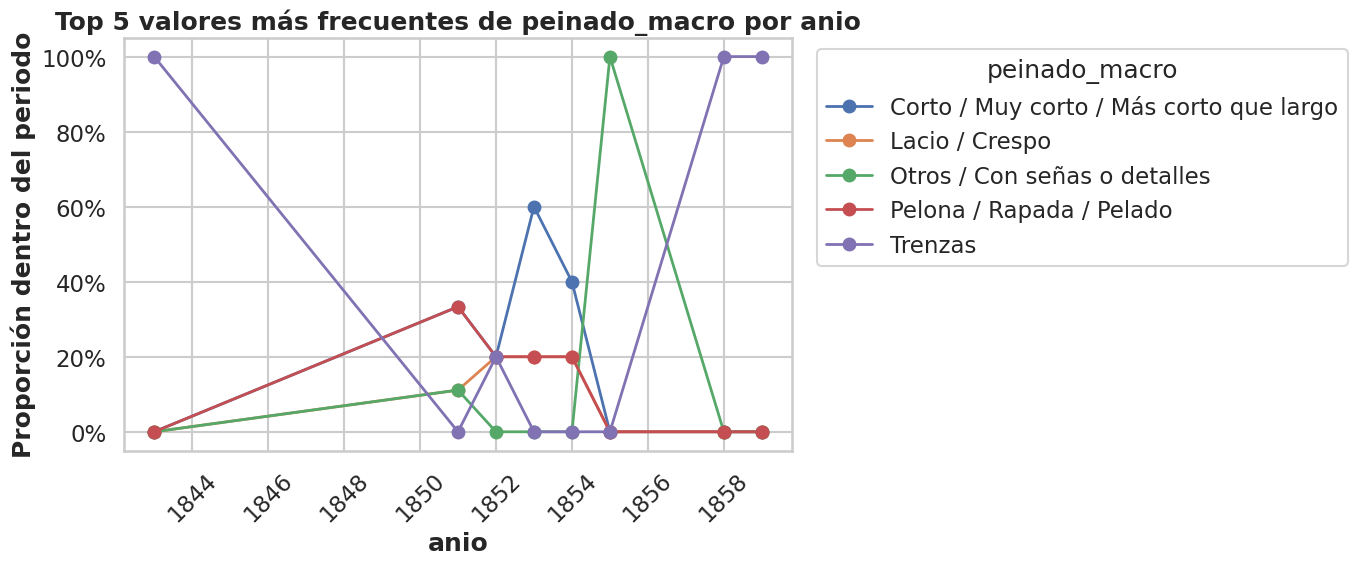

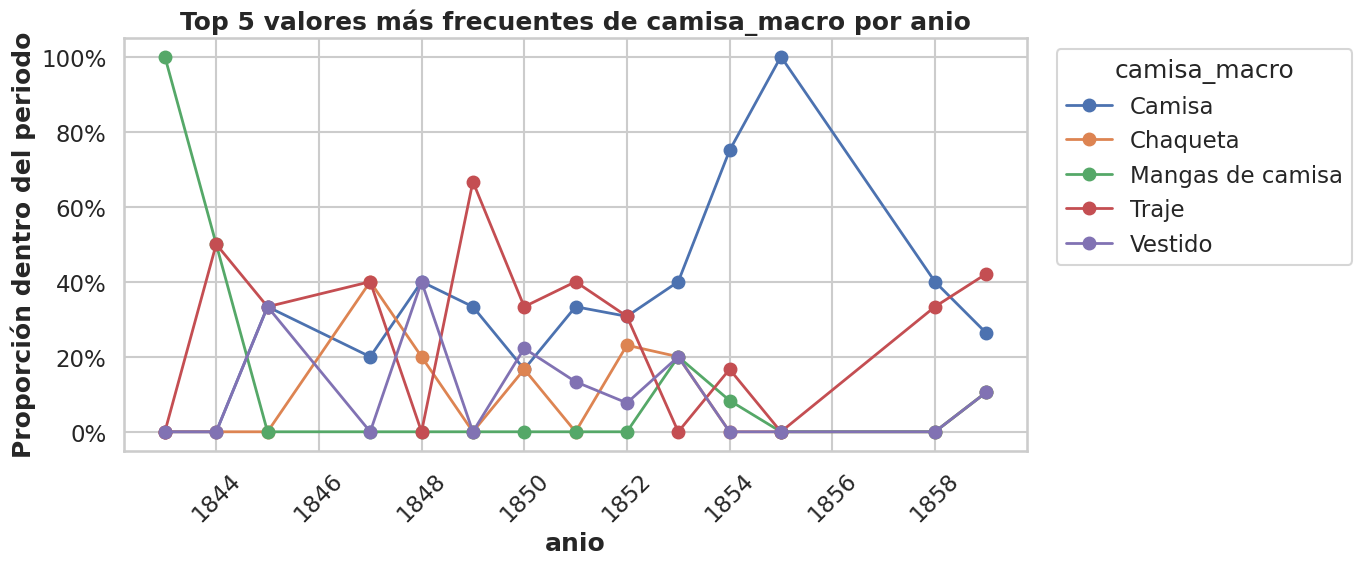

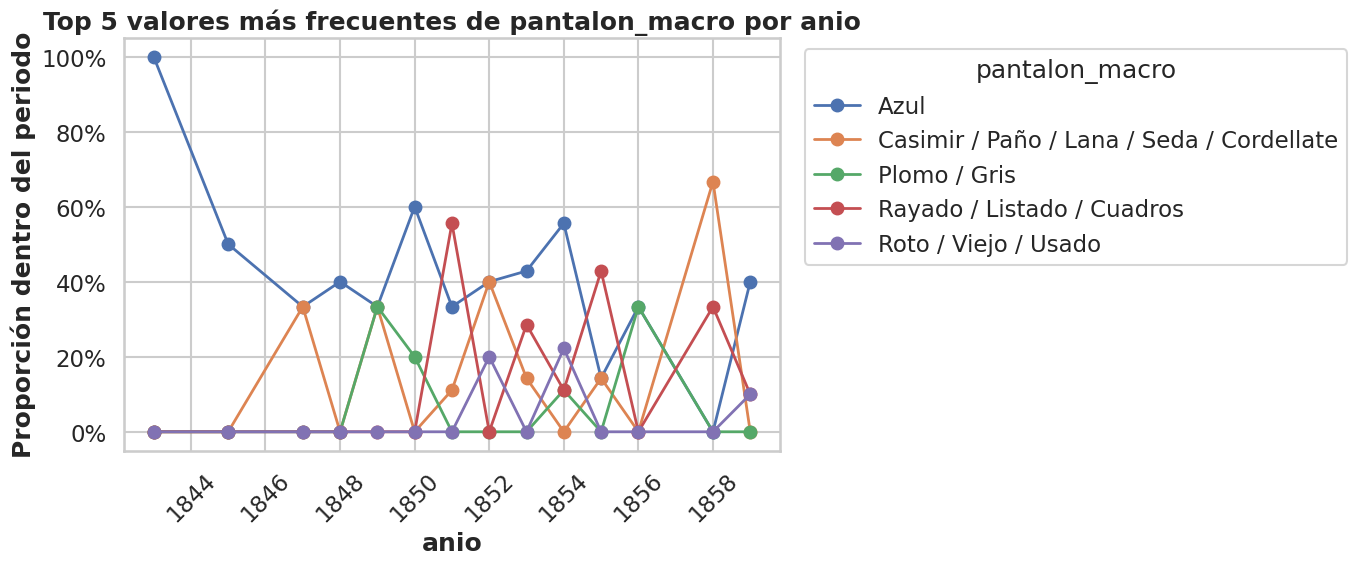

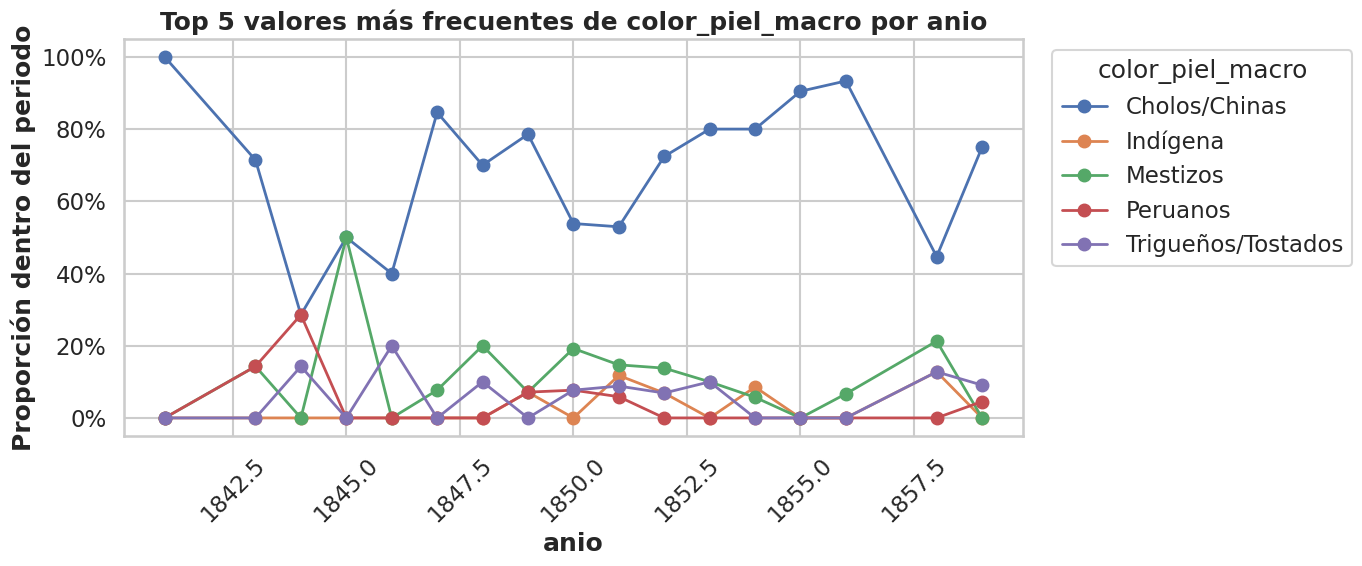

In [46]:
for columna in columnas_relevantes:
    plot_top_valores_por_periodo(df_av, "anio", variable=columna, top_n=5)

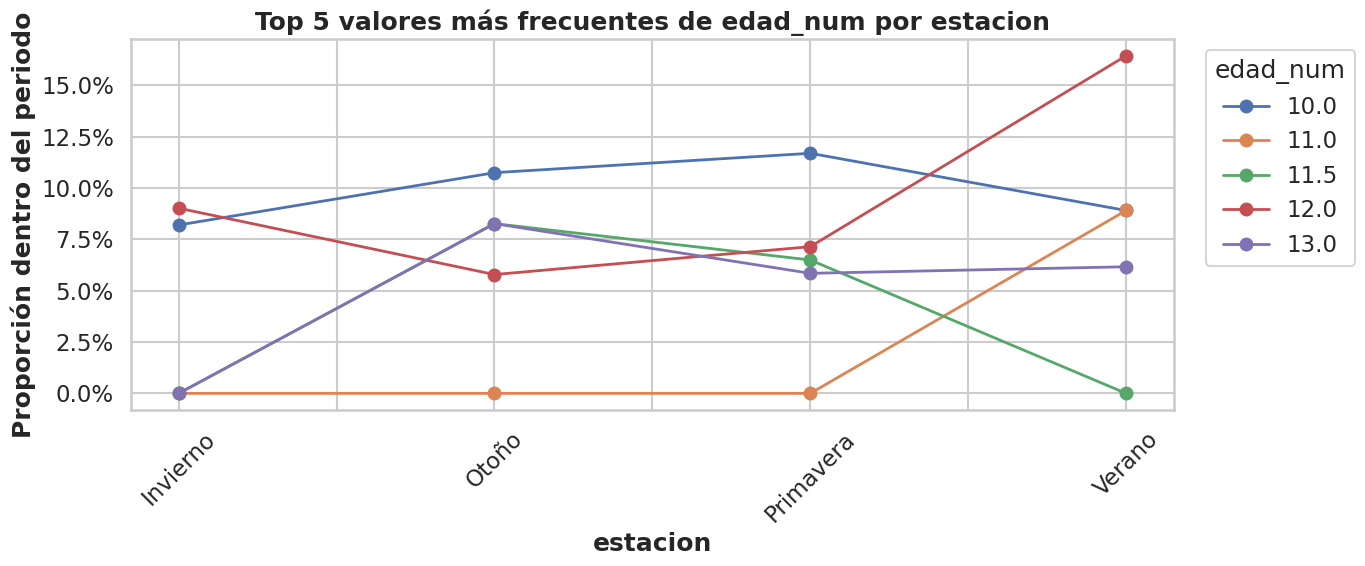

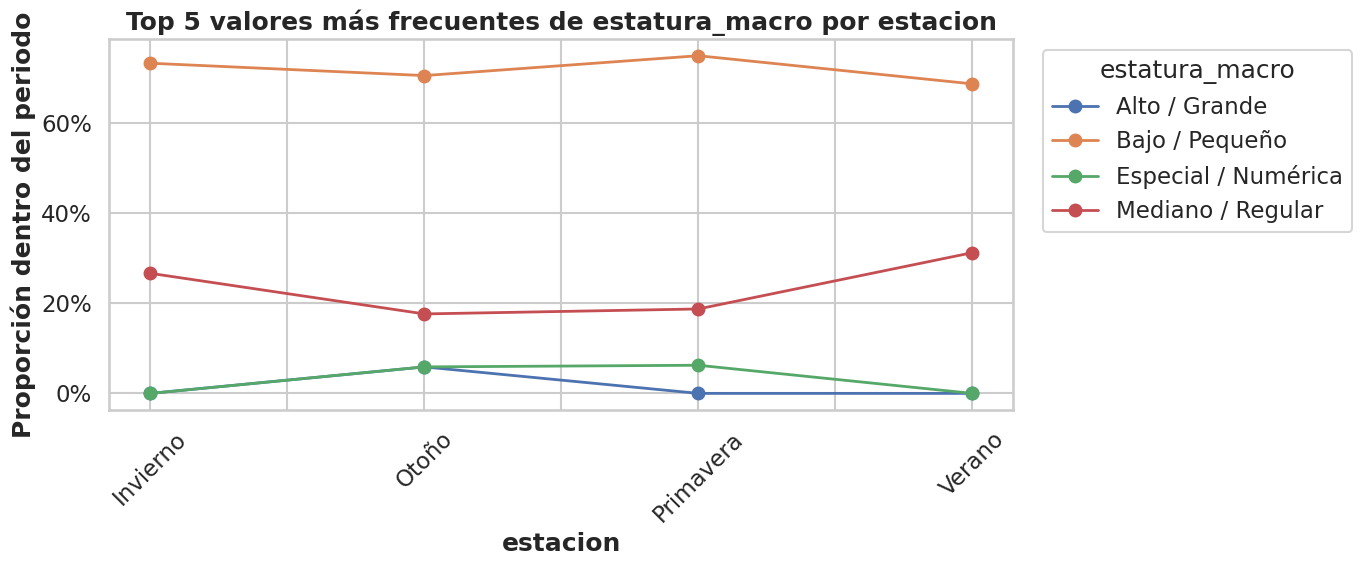

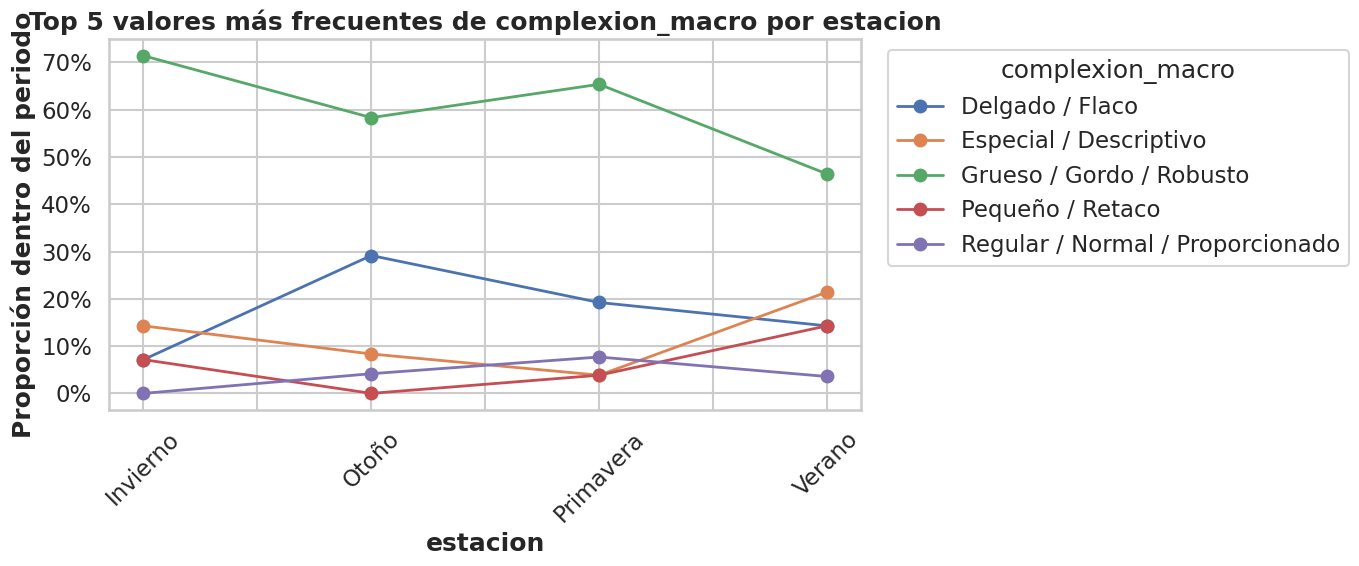

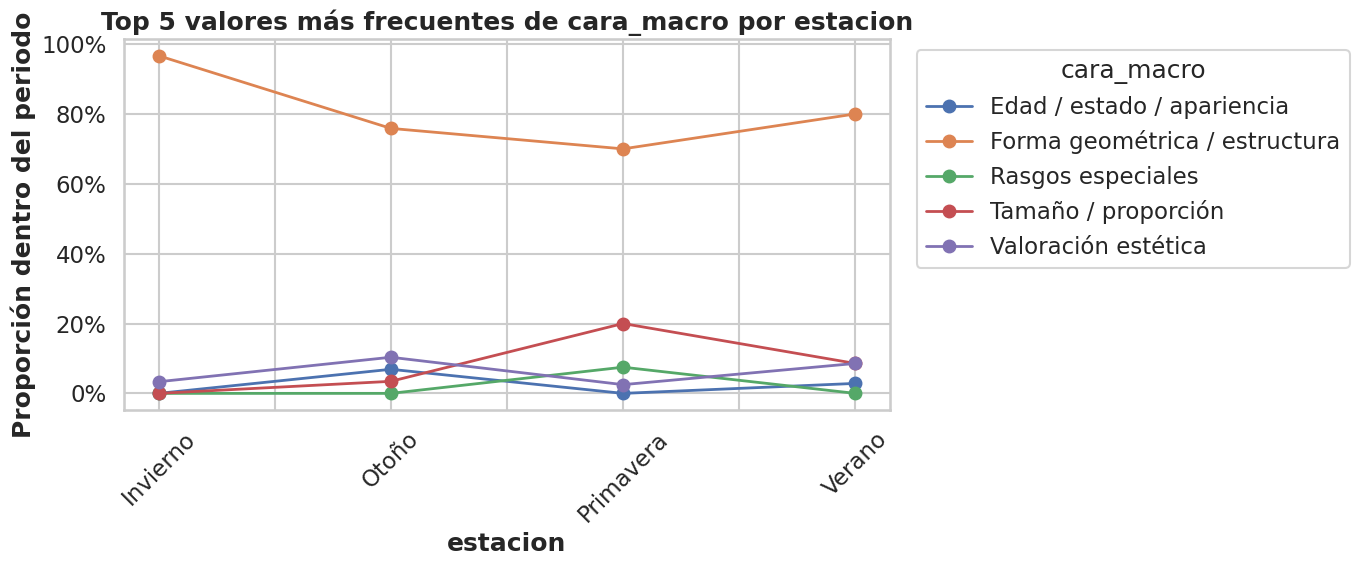

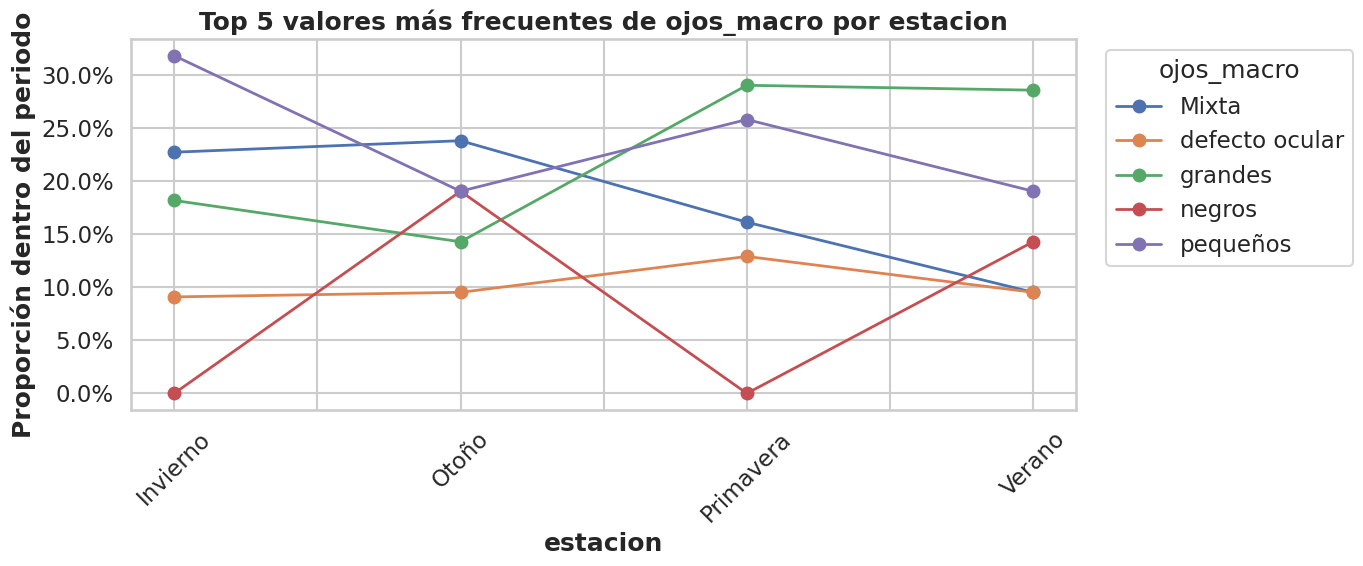

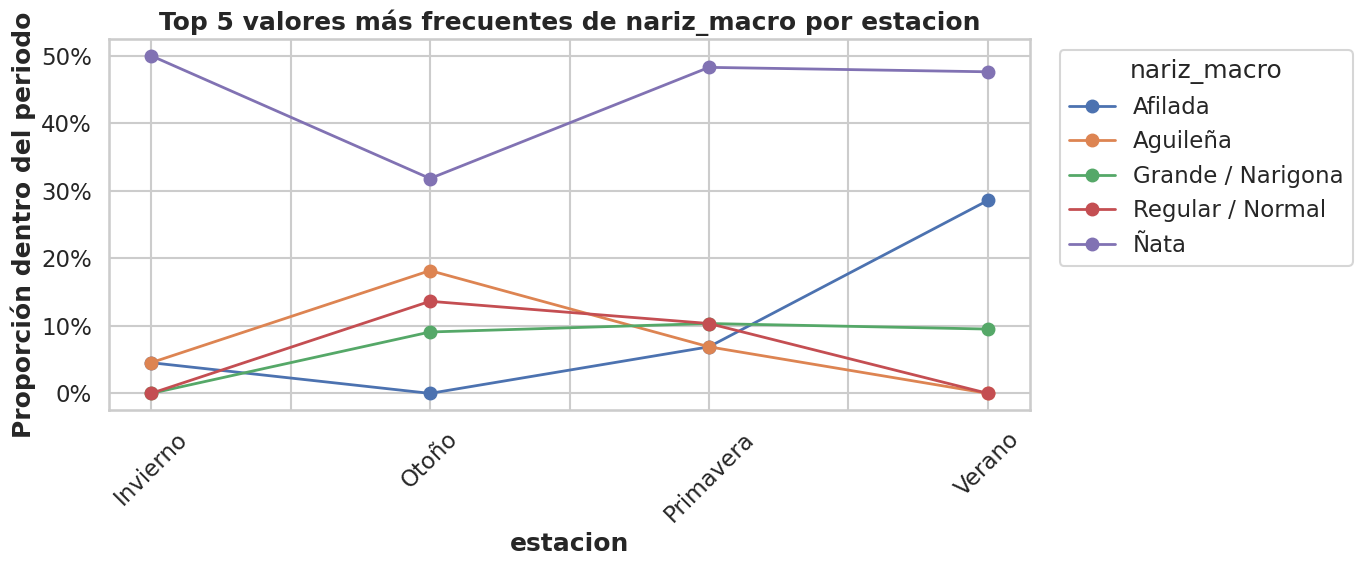

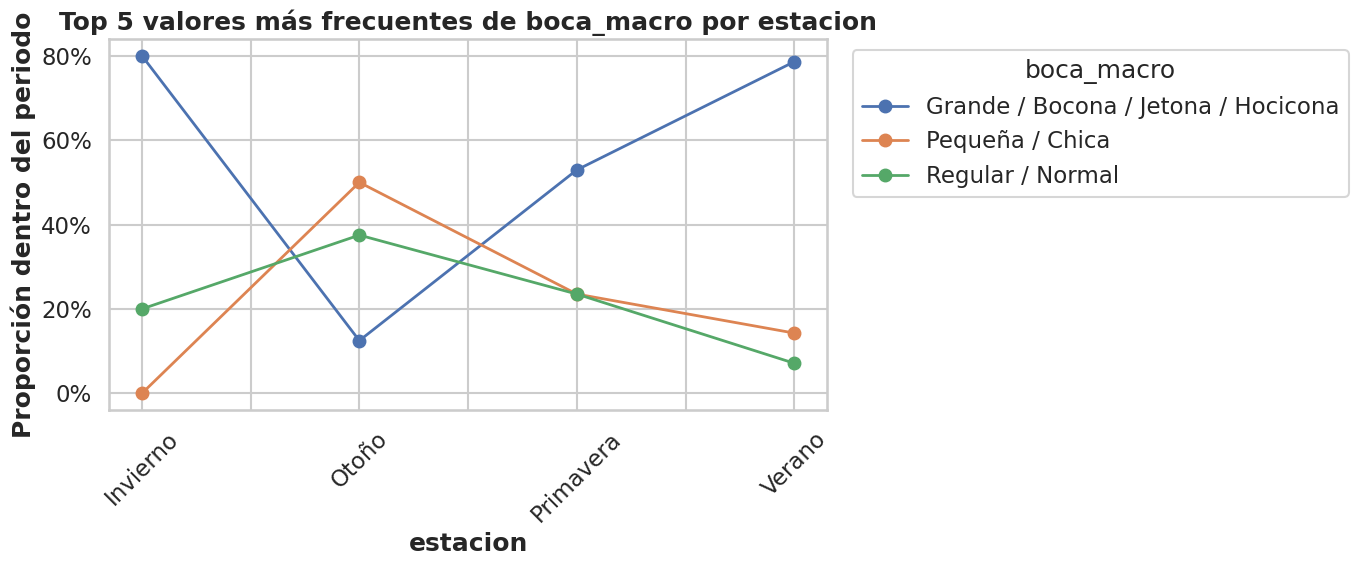

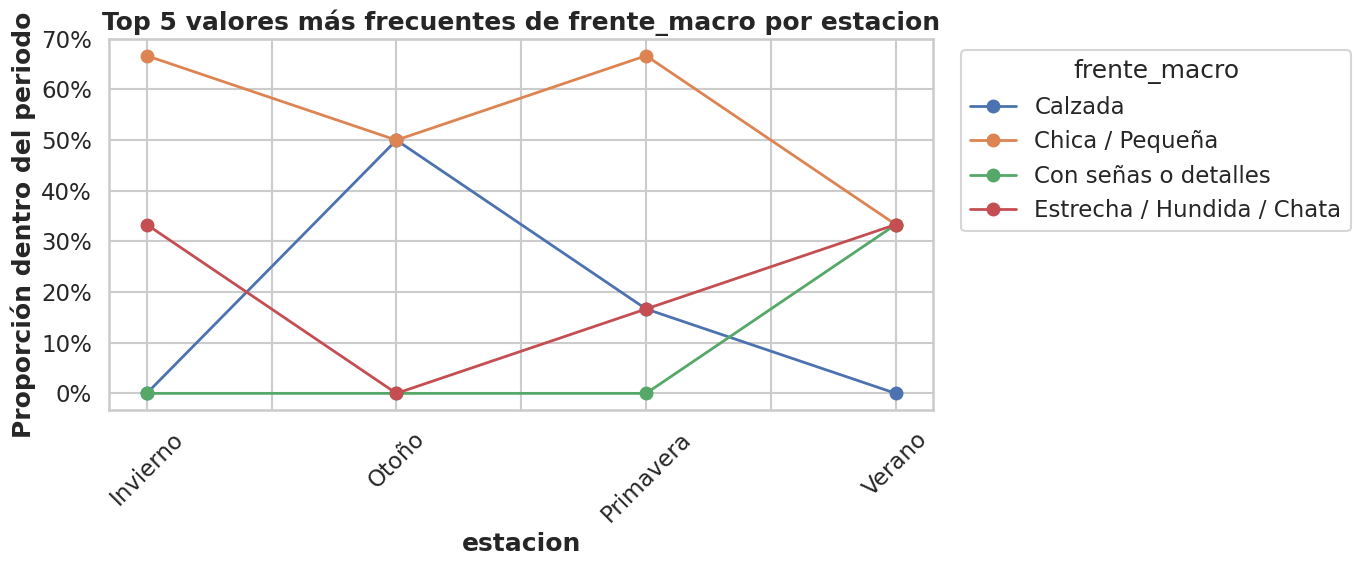

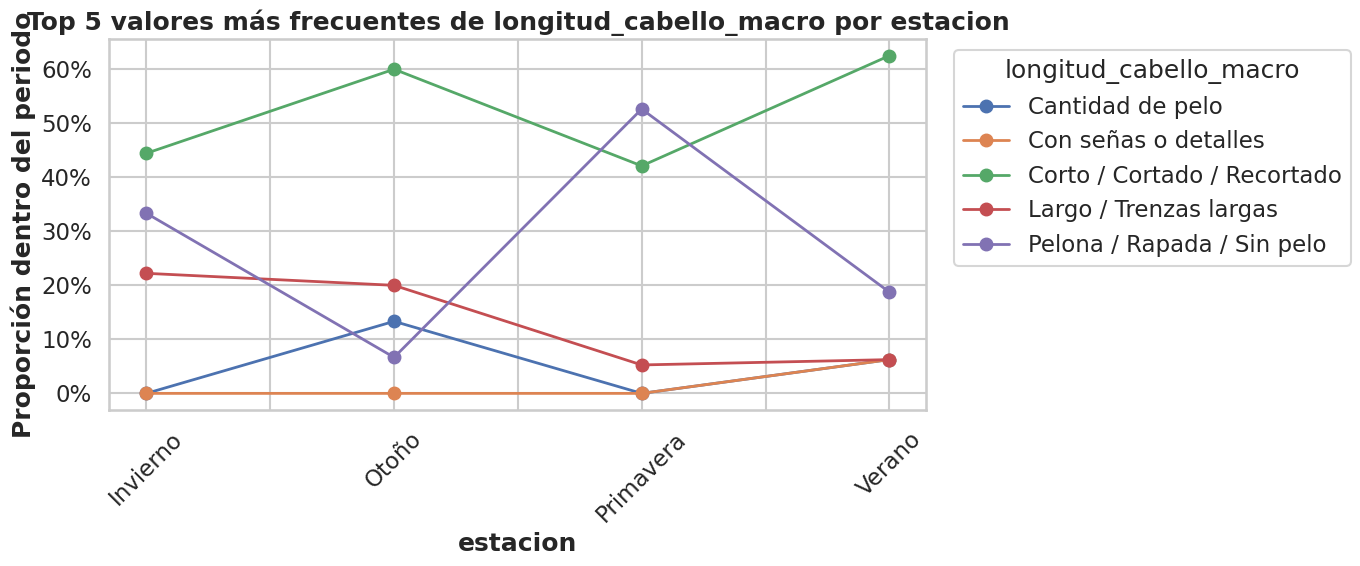

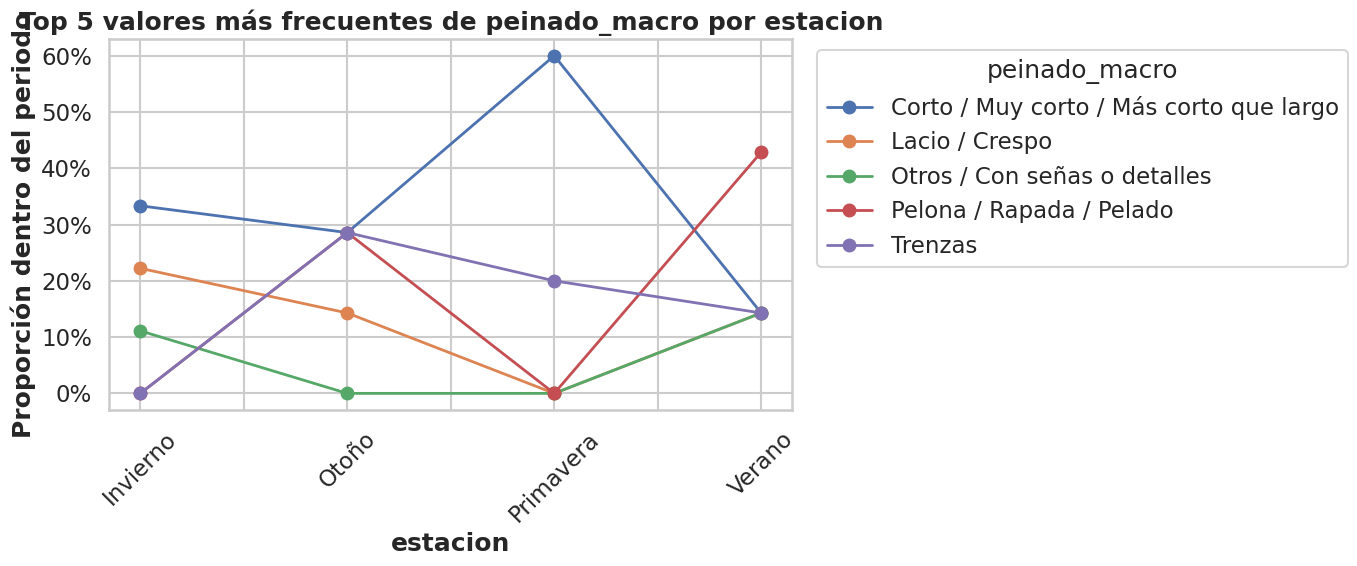

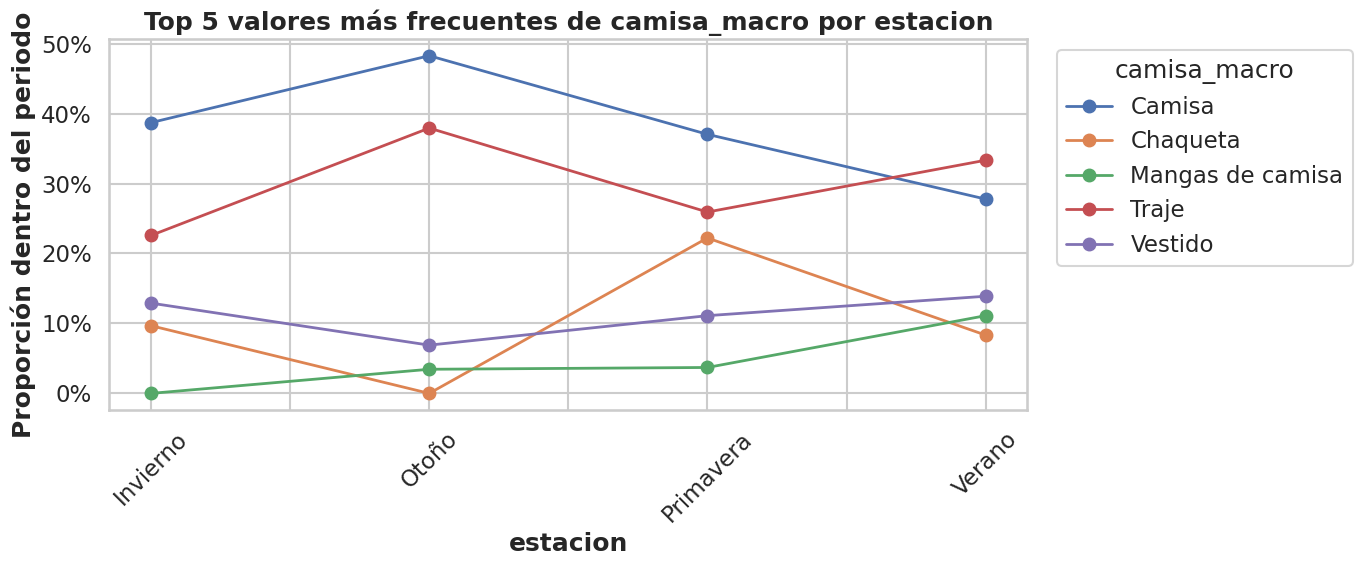

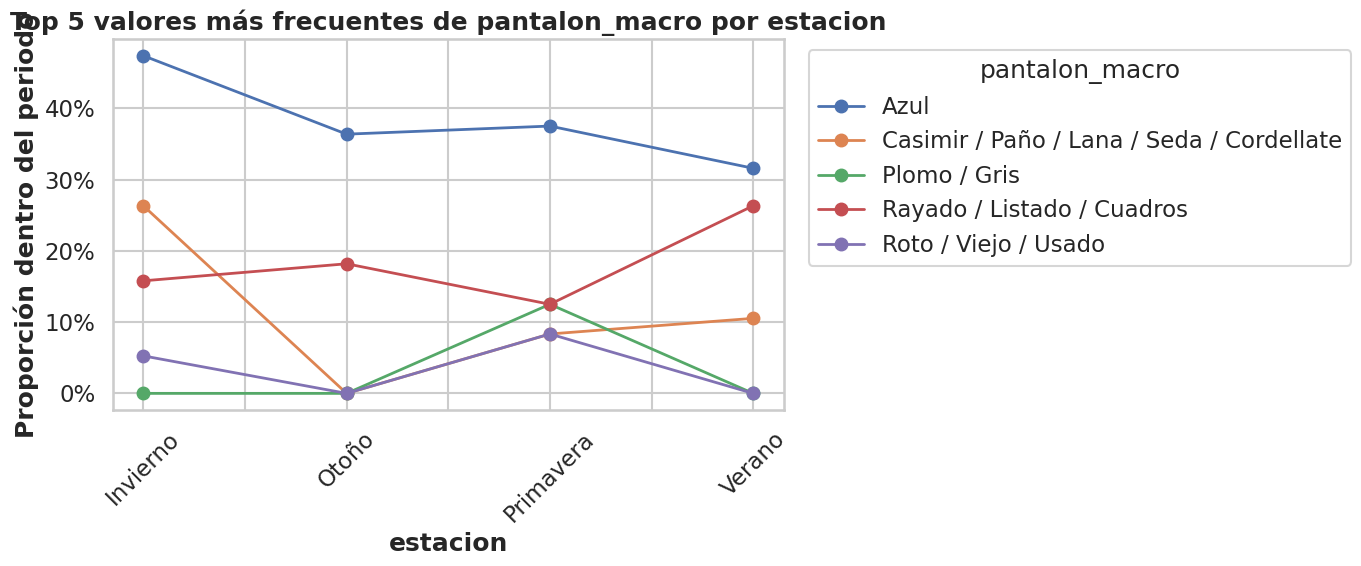

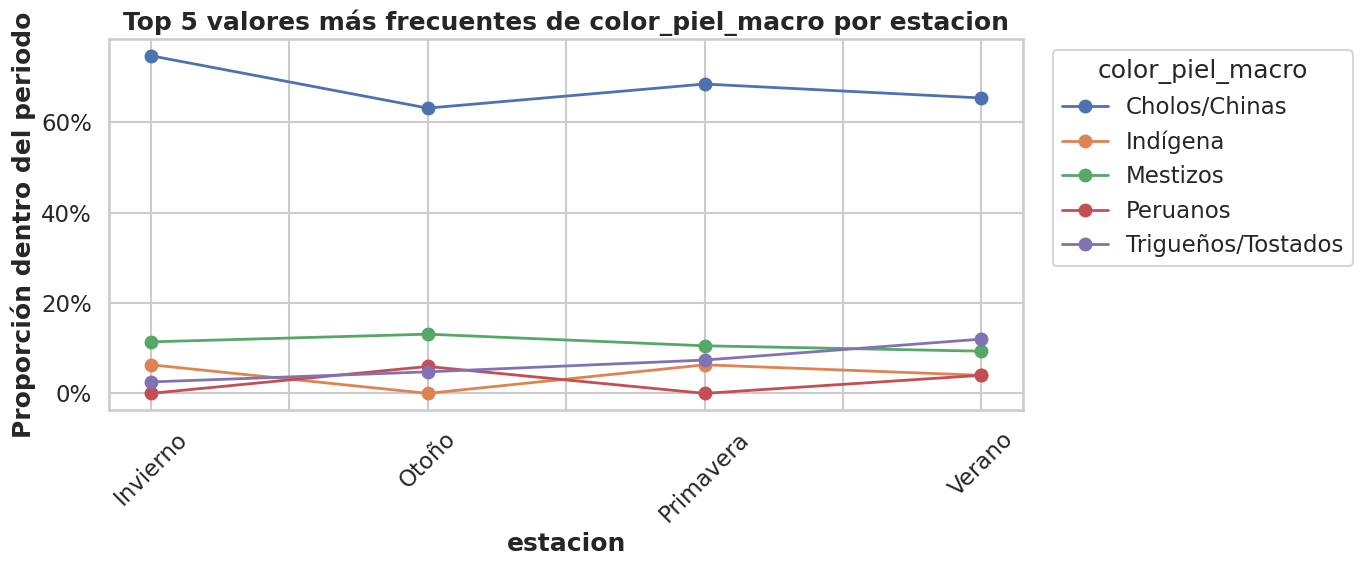

In [47]:
for columna in columnas_relevantes:
    plot_top_valores_por_periodo(df_av, "estacion", variable=columna, top_n=5)

In [ ]:
def concentracion_categoria(df: pd.DataFrame, periodo_col: str, variable: str) -> pd.DataFrame:
    tmp = df[[periodo_col, variable]].copy()
    tmp = tmp[mascara_valida(tmp[variable])]

    g = (
        tmp.groupby([periodo_col, variable], dropna=False)
        .size()
        .reset_index(name="frecuencia")
    )

    g["total_periodo"] = g.groupby(periodo_col)["frecuencia"].transform("sum")
    g["share"] = g["frecuencia"] / g["total_periodo"]

    resumen = (
        g.groupby(periodo_col)
        .agg(
            n_valores=(variable, "nunique"),
            share_top=("share", "max"),
            entropia=("share", lambda s: -(s * np.log2(s)).sum())
        )
        .reset_index()
    )
    return resumen

In [58]:
def bins_edad_desde_datos(serie: pd.Series, n_bins: int = 6) -> list[float]:
    valores = pd.to_numeric(serie, errors="coerce").dropna().values
    if len(valores) == 0:
        return []

    qs = np.linspace(0, 1, n_bins + 1)
    cortes = np.quantile(valores, qs)

    # Slight rounding so that bins remain readable
    cortes = np.unique(np.round(cortes, 0))

    # Ensure at least 2 edges
    if len(cortes) < 2:
        cortes = np.array([np.floor(np.min(valores)), np.ceil(np.max(valores))])

    # Extend edges to cover entire range
    cortes[0] = np.floor(np.min(valores))
    cortes[-1] = np.ceil(np.max(valores))

    return list(cortes)


cortes_edad = bins_edad_desde_datos(df_av["edad_num"], n_bins=6)
cortes_edad

[np.float64(1.0),
 np.float64(8.0),
 np.float64(10.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(50.0)]

In [60]:
df_av["edad_num_clean"] = pd.to_numeric(df_av["edad_num"], errors="coerce")

df_av["edad_bin"] = pd.cut(
    df_av["edad_num_clean"],
    bins=cortes_edad,
    include_lowest=True,
    duplicates="drop"
)

df_av["edad_bin"] = df_av["edad_bin"].astype("string")

def top_valores_edad(df, periodo_col, top_n=10):
    tmp = df[[periodo_col, "edad_bin"]].dropna()

    res = (
        tmp.groupby([periodo_col, "edad_bin"])
        .size()
        .reset_index(name="frecuencia")
    )

    res["total_periodo"] = res.groupby(periodo_col)["frecuencia"].transform("sum")
    res["share"] = res["frecuencia"] / res["total_periodo"]

    res = res.sort_values([periodo_col, "frecuencia"], ascending=[True, False])
    res["rank"] = res.groupby(periodo_col)["frecuencia"].rank(method="first", ascending=False)

    return res[res["rank"] <= top_n]


edad_por_decada = top_valores_edad(df_av, "periodo_decada", top_n=10)
edad_por_estacion = top_valores_edad(df_av, "estacion", top_n=10)

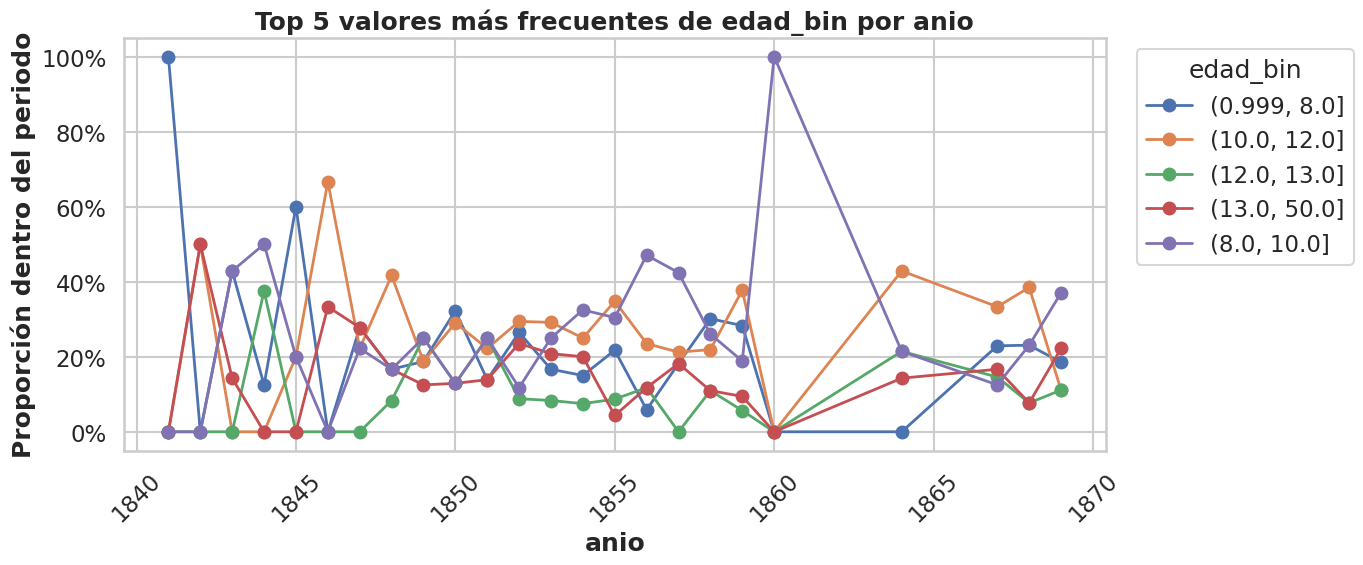

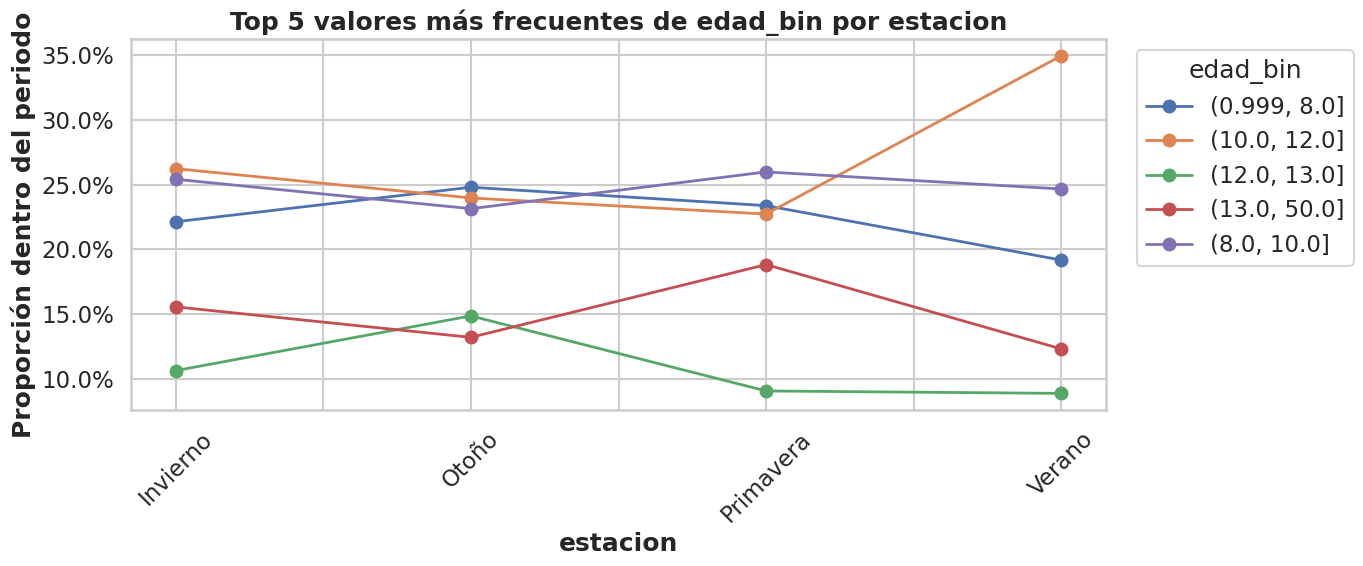

In [61]:
plot_top_valores_por_periodo(df_av, "anio", "edad_bin", top_n=5)
plot_top_valores_por_periodo(df_av, "estacion", "edad_bin", top_n=5)

In [62]:
publicaciones_por_aviso = (
    df_fuentes_por_aviso
    .groupby("id_aviso")
    .size()
    .reset_index(name="n_publicaciones")
)

df_pub = df_avisos_cholitos.merge(publicaciones_por_aviso, on="id_aviso", how="left")
df_pub["n_publicaciones"] = df_pub["n_publicaciones"].fillna(0)

In [63]:
df_pub["grupo_publicacion"] = pd.qcut(
    df_pub["n_publicaciones"],
    q=4,
    duplicates="drop"
)
df_pub["grupo_publicacion"] = df_pub["grupo_publicacion"].astype("string")

df_pub[["id_aviso", "n_publicaciones", "grupo_publicacion"]].head()

,id_aviso,n_publicaciones,grupo_publicacion
0,3,1,"(0.999, 3.0]"
1,4,1,"(0.999, 3.0]"
2,5,1,"(0.999, 3.0]"
3,6,1,"(0.999, 3.0]"
4,8,1,"(0.999, 3.0]"


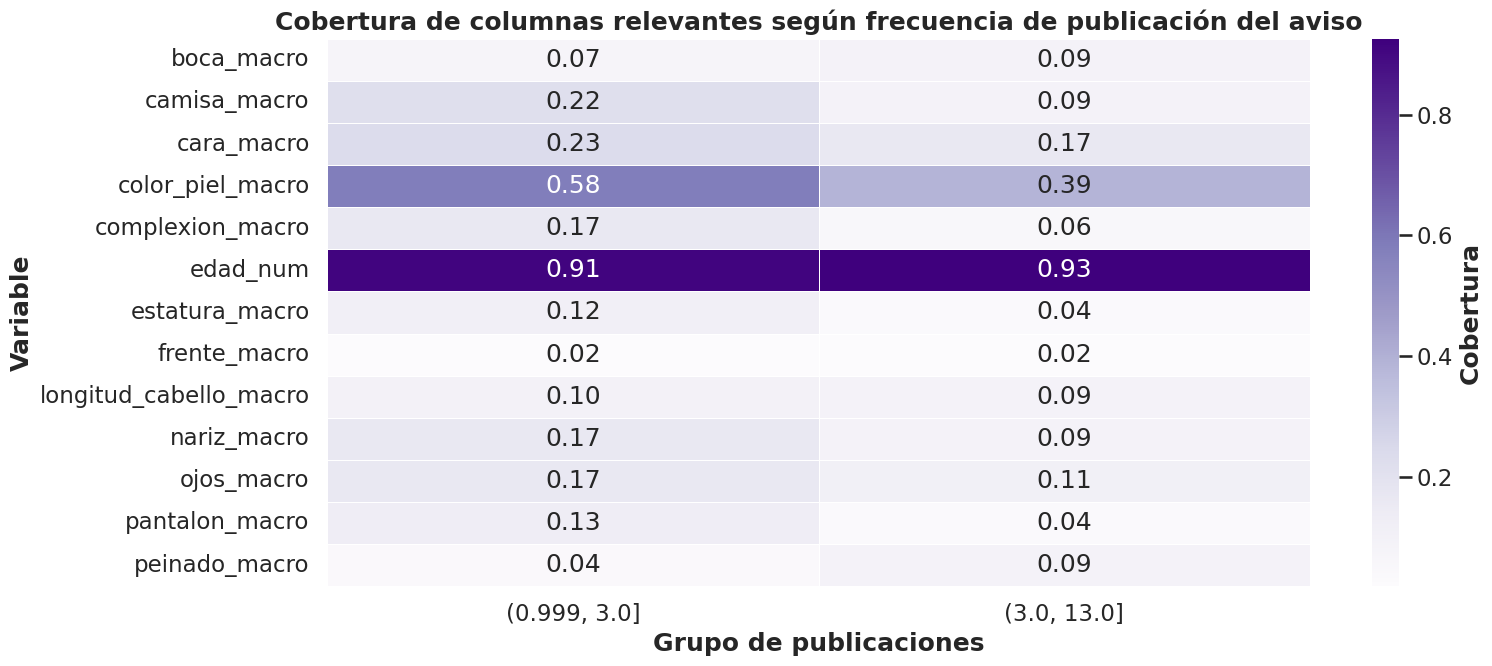

In [64]:
cobertura_pub = cobertura_por_periodo(df_pub, "grupo_publicacion", columnas_relevantes)

pivot_pub = cobertura_pub.pivot_table(
    index="variable",
    columns="grupo_publicacion",
    values="cobertura",
    aggfunc="mean"
)

plt.figure(figsize=(16, 7))
ax = sns.heatmap(
    pivot_pub,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Coverage"}
)
ax.set_title("Coverage of Relevant Variables by Notice Publication Frequency")
ax.set_xlabel("Publication Count Group")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

In [65]:
resumen_pub = (
    df_pub.assign(**{c: mascara_valida(df_pub[c]).astype(int) for c in columnas_relevantes})
    .groupby("grupo_publicacion")[columnas_relevantes]
    .mean()
    .T
)

resumen_pub

grupo_publicacion,"(0.999, 3.0]","(3.0, 13.0]"
edad_num,0.914657,0.925926
estatura_macro,0.115028,0.037037
complexion_macro,0.165121,0.055556
cara_macro,0.231911,0.166667
ojos_macro,0.165121,0.111111
nariz_macro,0.165121,0.092593
boca_macro,0.072356,0.092593
frente_macro,0.024119,0.018519
longitud_cabello_macro,0.100186,0.092593
peinado_macro,0.042672,0.092593


In [66]:
comparacion_pub = []
for col in columnas_relevantes:
    tmp = df_pub[[col, "n_publicaciones"]].copy()
    tmp["presente"] = mascara_valida(tmp[col])

    comparacion_pub.append({
        "variable": col,
        "media_pub_presente": tmp.loc[tmp["presente"], "n_publicaciones"].mean(),
        "media_pub_ausente": tmp.loc[~tmp["presente"], "n_publicaciones"].mean(),
        "dif": tmp.loc[tmp["presente"], "n_publicaciones"].mean() - tmp.loc[~tmp["presente"], "n_publicaciones"].mean(),
        "n_presente": tmp["presente"].sum(),
        "n_ausente": (~tmp["presente"]).sum()
    })

comparacion_pub = pd.DataFrame(comparacion_pub).sort_values("dif", ascending=False)
comparacion_pub

,variable,media_pub_presente,media_pub_ausente,dif,n_presente,n_ausente
9,peinado_macro,2.500000,1.884956,0.615044,28,565
0,edad_num,1.933702,1.700000,0.233702,543,50
6,boca_macro,2.090909,1.899818,0.191091,44,549
4,ojos_macro,1.800000,1.935743,-0.135743,95,498
3,cara_macro,1.768657,1.956427,-0.187770,134,459
5,nariz_macro,1.755319,1.943888,-0.188569,94,499
8,longitud_cabello_macro,1.728814,1.934457,-0.205643,59,534
10,camisa_macro,1.723577,1.963830,-0.240253,123,470
11,pantalon_macro,1.684932,1.946154,-0.261222,73,520
7,frente_macro,1.642857,1.920553,-0.277696,14,579


In [67]:
def valores_vs_publicaciones(df: pd.DataFrame, variable: str, top_n: int = 10) -> pd.DataFrame:
    tmp = df[[variable, "n_publicaciones"]].copy()
    tmp = tmp[mascara_valida(tmp[variable])]

    res = (
        tmp.groupby(variable)
        .agg(
            frecuencia=(variable, "size"),
            media_publicaciones=("n_publicaciones", "mean"),
            mediana_publicaciones=("n_publicaciones", "median")
        )
        .reset_index()
        .sort_values(["frecuencia", "media_publicaciones"], ascending=[False, False])
    )
    return res.head(top_n)

In [68]:
valores_vs_publicaciones(df_pub, "peinado_macro", top_n=10)
valores_vs_publicaciones(df_pub, "cara_macro", top_n=10)

,cara_macro,frecuencia,media_publicaciones,mediana_publicaciones
1,Forma geométrica / estructura,107,1.831776,1.0
4,Tamaño / proporción,12,1.833333,1.5
5,Valoración estética,8,1.375000,1.0
2,Rasgos especiales,3,1.333333,1.0
0,Edad / estado / apariencia,3,1.000000,1.0
3,Regular / neutral,1,1.000000,1.0


In [69]:
resumen_cobertura.to_csv("../data/resumen_cobertura.csv", index=False, encoding="utf-8")
cobertura_decada.to_csv("../data/cobertura_decada.csv", index=False, encoding="utf-8")
cobertura_estacion.to_csv("../data/cobertura_estacion.csv", index=False, encoding="utf-8")
cobertura_anio_estacion.to_csv("../data/cobertura_anio_estacion.csv", index=False, encoding="utf-8")
comparacion_pub.to_csv("../data/comparacion_pub.csv", index=False, encoding="utf-8")